# 6.13 - CertCF proximity distribution histograms

This notebook reads saved CertCF benchmark parquet results and visualizes the full per-query distributions of proximity metrics.

Main focus:
- `l1_distance`
- `l2_distance`

The default input is the latest prediction-aligned input-vs-latent CertCF benchmark:

```text
results/benchmark_meeting_certcf_input_vs_latent_200q.parquet
```

The notebook does not rebuild atlases or rerun queries. It only reads saved results.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from IPython.display import display
from sklearn.decomposition import PCA

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from counterfactuals.benchmarks.registry import create_default_registries
from notebooks.utils import load_result, method_comparison_summary, prepare_benchmark_df, setup_notebook_style

RESULT_PATH = ROOT / 'results/benchmark_meeting_certcf_input_vs_latent_200q.parquet'
CONFIG_PATH = ROOT / 'configs/benchmarks/benchmark_meeting_certcf_input_vs_latent_200q.yaml'
FIGURE_DIR = ROOT / 'results/figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

setup_notebook_style()
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

print(RESULT_PATH)
print(FIGURE_DIR)


/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/results/benchmark_meeting_certcf_input_vs_latent_200q.parquet
/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/results/figures


In [2]:
method_labels = {
    'certcf_input_kmedoids': 'input k-medoids',
    'certcf_latent_kmedoids': 'latent k-medoids',
}
df = load_result(RESULT_PATH, method_labels=method_labels)

required = {'dataset', 'method', 'success', 'query_idx', 'l1_distance', 'l2_distance'}
missing = sorted(required.difference(df.columns))
if missing:
    raise ValueError(f'Missing required columns in {RESULT_PATH}: {missing}')

success_df = prepare_benchmark_df(df, success_only_rows=True)
print(f'rows: {len(df):,}')
print(f'success rows: {len(success_df):,}')
print('datasets:', sorted(df['dataset'].dropna().unique().tolist()))
print('methods:', sorted(df['method'].dropna().unique().tolist()))

validity = method_comparison_summary(df, order=['input k-medoids', 'latent k-medoids'])
display(validity[['dataset', 'method_label', 'n', 'valid_pct']].rename(columns={'n': 'total', 'valid_pct': 'validity_pct'}))


rows: 1,000
success rows: 1,000
datasets: ['adult', 'compas', 'german_credit']
methods: ['certcf_input_kmedoids', 'certcf_latent_kmedoids']


,dataset,method_label,valid,total,validity_pct
0,adult,input k-medoids,200,200,100.0
1,adult,latent k-medoids,200,200,100.0
2,compas,input k-medoids,200,200,100.0
3,compas,latent k-medoids,200,200,100.0
4,german_credit,input k-medoids,100,100,100.0
5,german_credit,latent k-medoids,100,100,100.0


## Summary Quantiles

Means are useful but can hide skewed tails. This table shows distribution quantiles for both proximity metrics.

In [3]:
quantiles = [0.10, 0.25, 0.50, 0.75, 0.90]
quantile_table = (
    success_df
    .groupby(['dataset', 'method_label'])[['l1_distance', 'l2_distance']]
    .quantile(quantiles)
    .rename_axis(index=['dataset', 'method', 'quantile'])
    .round(4)
)
display(quantile_table)

mean_table = (
    success_df
    .groupby(['dataset', 'method_label'], as_index=False)[['l1_distance', 'l2_distance']]
    .mean()
    .rename(columns={'method_label': 'method', 'l1_distance': 'l1_mean', 'l2_distance': 'l2_mean'})
    .round(4)
)
display(mean_table)

l1_distance  l2_distance
dataset       method           quantile                          
adult         input k-medoids  0.10           3.6095       1.7649
                               0.25           5.7520       2.4592
                               0.50           7.5898       2.8644
                               0.75           9.8682       3.4313
                               0.90          11.8819       3.9403
              latent k-medoids 0.10           4.0986       1.9165
                               0.25           5.8569       2.5202
                               0.50           7.8786       2.9243
                               0.75           9.7314       3.4426
                               0.90          11.6212       4.0667
compas        input k-medoids  0.10           0.3064       0.2278
                               0.25           0.6004       0.4824
                               0.50           1.2826       1.0297
                               0.75           2.6215       1.7530
                               0.90           3.8313       2.4880
              latent k-medoids 0.10           0.2693       0.2035
                               0.25           0.5929       0.5099
                               0.50           1.2178       1.0154
                               0.75           2.5760       1.6774
                               0.90           3.5623       2.3684
german_credit input k-medoids  0.10           7.5074       2.7028
                               0.25           8.5482       2.9919
                               0.50          10.0390       3.3062
                               0.75          11.8513       3.8484
                               0.90          13.7269       4.2653
              latent k-medoids 0.10           7.5074       2.7028
                               0.25           8.5712       2.9981
                               0.50          10.2818       3.3366
                               0.75          11.9595       3.8340
                               0.90          13.4914       4.2668

,dataset,method,l1_mean,l2_mean
0,adult,input k-medoids,7.6940,2.9303
1,adult,latent k-medoids,7.8605,3.0324
2,compas,input k-medoids,1.7409,1.2261
3,compas,latent k-medoids,1.6989,1.1999
4,german_credit,input k-medoids,10.4611,3.4301
5,german_credit,latent k-medoids,10.4794,3.4328


## Histograms By Dataset

Each row is one dataset. Columns show the empirical distributions of `L1` and `L2` proximity. Curves are density-normalized within method, so shapes are comparable even if methods have different numbers of successful rows.

/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/results/figures/certcf_proximity_histograms_by_dataset.png


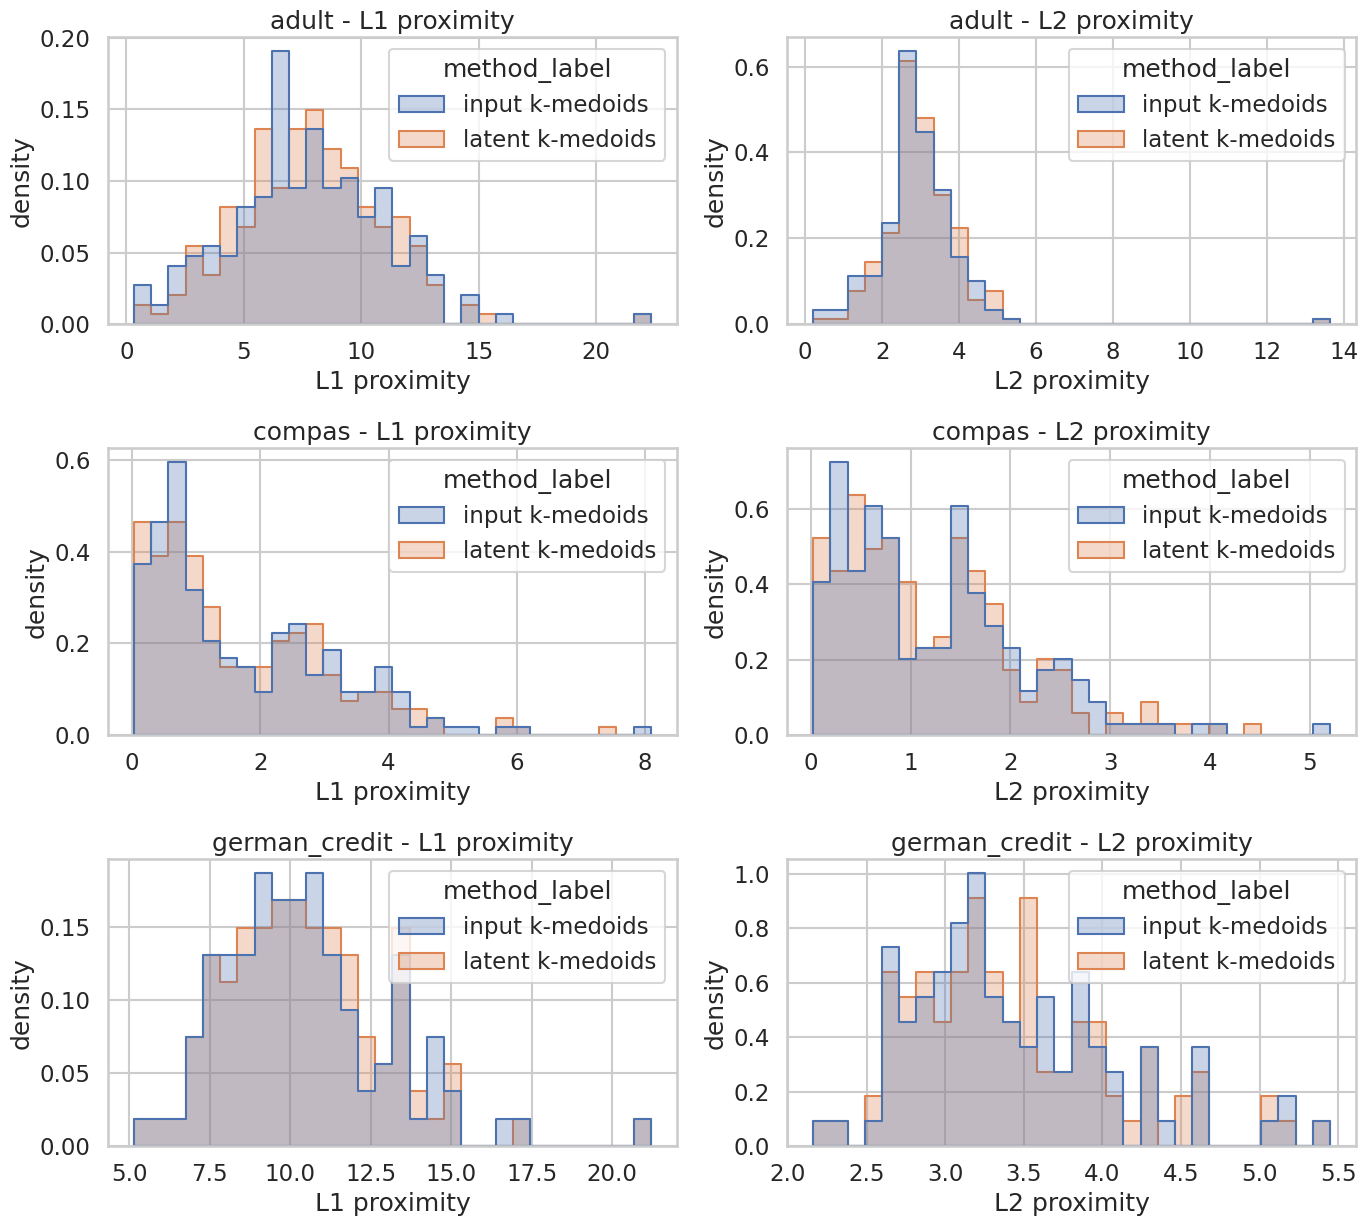

In [4]:
metrics = [
    ('l1_distance', 'L1 proximity'),
    ('l2_distance', 'L2 proximity'),
]
datasets = sorted(success_df['dataset'].dropna().unique().tolist())

fig, axes = plt.subplots(
    nrows=len(datasets),
    ncols=len(metrics),
    figsize=(14, 4.2 * len(datasets)),
    squeeze=False,
)

for r, dataset in enumerate(datasets):
    sub = success_df[success_df['dataset'] == dataset]
    for c, (metric, label) in enumerate(metrics):
        ax = axes[r, c]
        sns.histplot(
            data=sub,
            x=metric,
            hue='method_label',
            bins=30,
            stat='density',
            common_norm=False,
            element='step',
            fill=True,
            alpha=0.30,
            ax=ax,
        )
        ax.set_title(f'{dataset} - {label}')
        ax.set_xlabel(label)
        ax.set_ylabel('density')

fig.tight_layout()
hist_path = FIGURE_DIR / 'certcf_proximity_histograms_by_dataset.png'
fig.savefig(hist_path, dpi=180, bbox_inches='tight')
print(hist_path)

## ECDF View

Histograms are sensitive to binning. ECDF plots make it easier to compare which method has more mass at lower proximity values.

/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/results/figures/certcf_proximity_ecdf_by_dataset.png


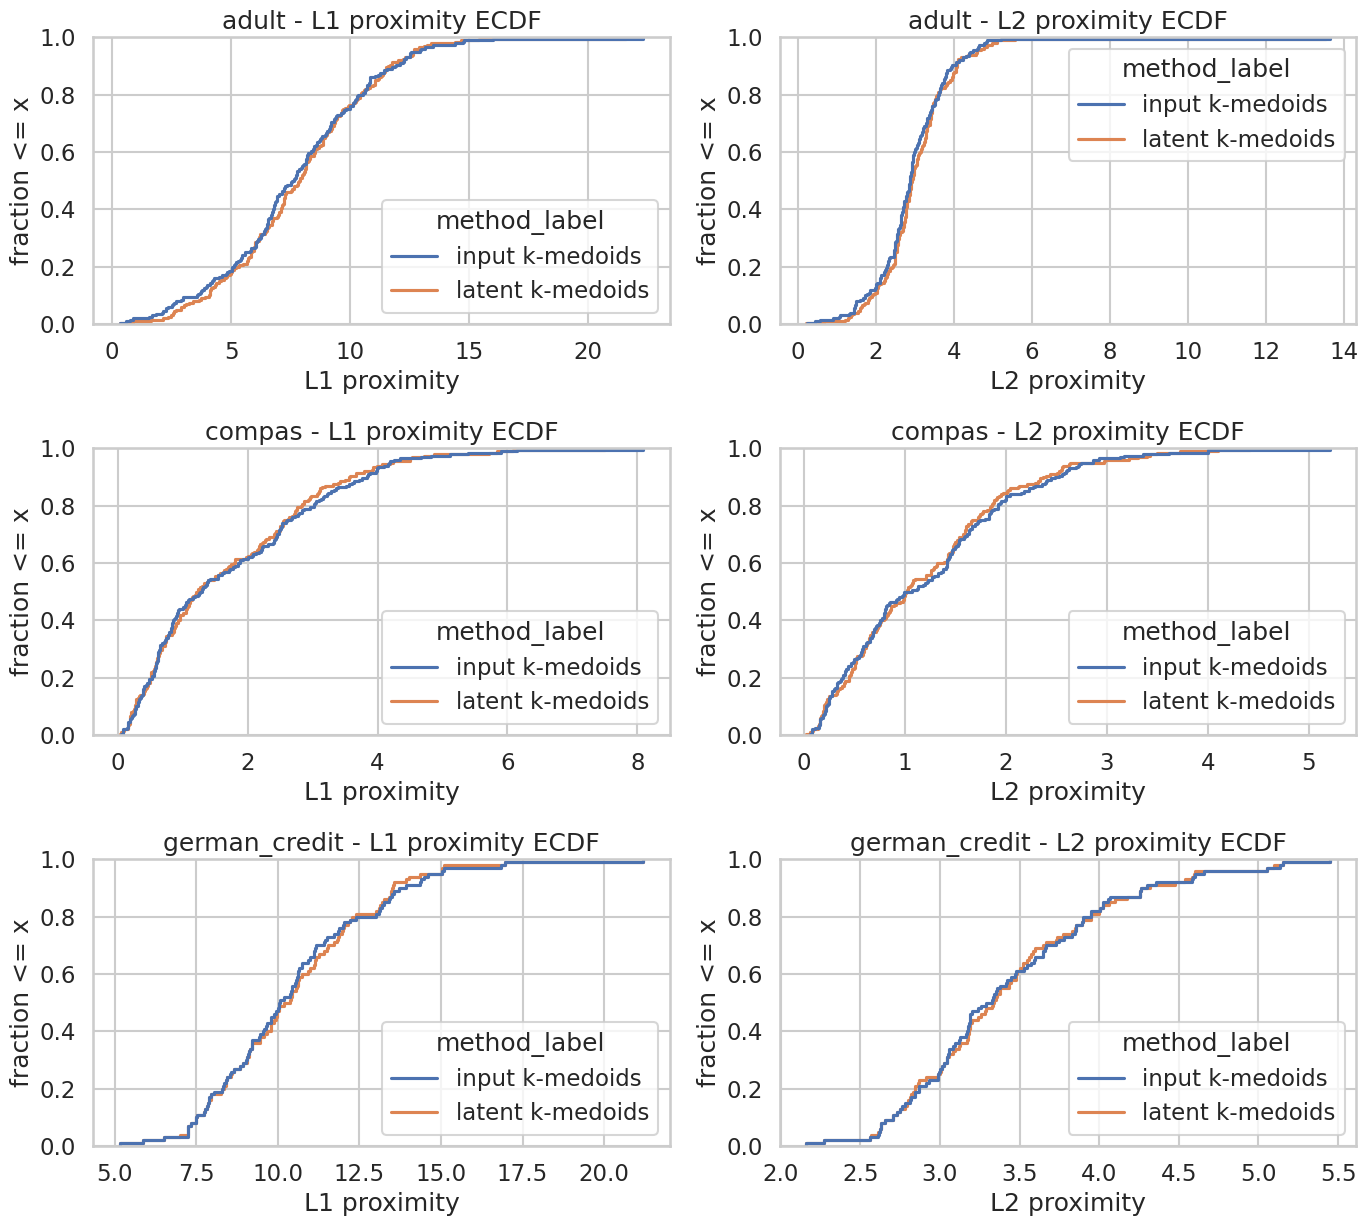

In [5]:
fig, axes = plt.subplots(
    nrows=len(datasets),
    ncols=len(metrics),
    figsize=(14, 4.2 * len(datasets)),
    squeeze=False,
)

for r, dataset in enumerate(datasets):
    sub = success_df[success_df['dataset'] == dataset]
    for c, (metric, label) in enumerate(metrics):
        ax = axes[r, c]
        sns.ecdfplot(data=sub, x=metric, hue='method_label', ax=ax)
        ax.set_title(f'{dataset} - {label} ECDF')
        ax.set_xlabel(label)
        ax.set_ylabel('fraction <= x')

fig.tight_layout()
ecdf_path = FIGURE_DIR / 'certcf_proximity_ecdf_by_dataset.png'
fig.savefig(ecdf_path, dpi=180, bbox_inches='tight')
print(ecdf_path)

## Paired Latent Minus Input Deltas

Because both methods run on the same query set, this view compares them query-by-query.

Negative values mean `latent k-medoids` found a closer counterfactual than `input k-medoids` for that query.

mean  median     p10     p90    n
dataset       metric_label                                     
adult         L1 proximity  0.1665  0.1326 -1.2707  1.5460  200
              L2 proximity  0.1020  0.0651 -0.5322  0.6829  200
compas        L1 proximity -0.0420 -0.0045 -0.3412  0.2814  200
              L2 proximity -0.0262  0.0000 -0.3739  0.2512  200
german_credit L1 proximity  0.0183  0.0000 -0.0294  0.2946  100
              L2 proximity  0.0027  0.0000 -0.0090  0.0312  100

/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/results/figures/certcf_proximity_delta_histograms_by_dataset.png


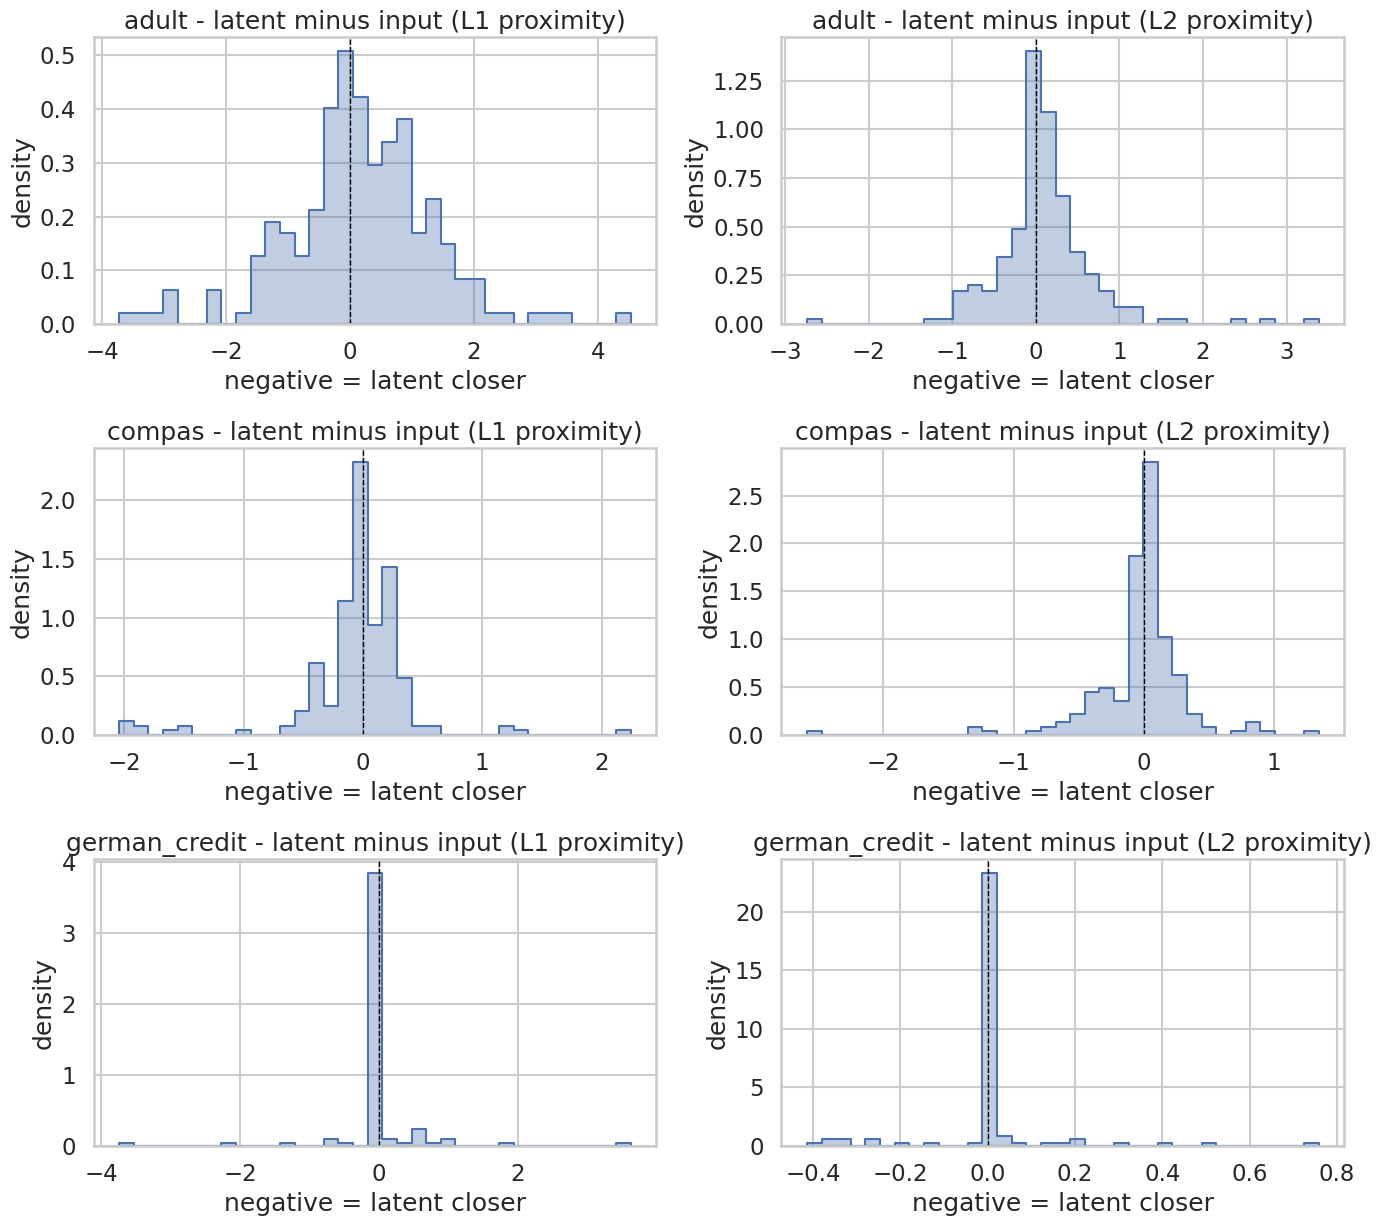

In [6]:
expected_methods = {'certcf_input_kmedoids', 'certcf_latent_kmedoids'}
if expected_methods.issubset(set(success_df['method'].unique())):
    paired = success_df.pivot_table(
        index=['dataset', 'query_idx'],
        columns='method',
        values=['l1_distance', 'l2_distance'],
    )
    delta_rows = []
    for metric, label in metrics:
        delta = paired[(metric, 'certcf_latent_kmedoids')] - paired[(metric, 'certcf_input_kmedoids')]
        tmp = delta.rename('latent_minus_input').reset_index()
        tmp['metric'] = metric
        tmp['metric_label'] = label
        delta_rows.append(tmp)
    delta_df = pd.concat(delta_rows, ignore_index=True).dropna()
else:
    delta_df = pd.DataFrame(columns=['dataset', 'query_idx', 'latent_minus_input', 'metric', 'metric_label'])

display(
    delta_df
    .groupby(['dataset', 'metric_label'])['latent_minus_input']
    .agg(mean='mean', median='median', p10=lambda s: s.quantile(0.10), p90=lambda s: s.quantile(0.90), n='count')
    .round(4)
)

fig, axes = plt.subplots(
    nrows=len(datasets),
    ncols=len(metrics),
    figsize=(14, 4.2 * len(datasets)),
    squeeze=False,
)

for r, dataset in enumerate(datasets):
    for c, (metric, label) in enumerate(metrics):
        ax = axes[r, c]
        sub = delta_df[(delta_df['dataset'] == dataset) & (delta_df['metric'] == metric)]
        sns.histplot(data=sub, x='latent_minus_input', bins=35, stat='density', element='step', fill=True, alpha=0.35, ax=ax)
        ax.axvline(0.0, color='black', linestyle='--', linewidth=1)
        ax.set_title(f'{dataset} - latent minus input ({label})')
        ax.set_xlabel('negative = latent closer')
        ax.set_ylabel('density')

fig.tight_layout()
delta_path = FIGURE_DIR / 'certcf_proximity_delta_histograms_by_dataset.png'
fig.savefig(delta_path, dpi=180, bbox_inches='tight')
print(delta_path)

## Worst-Tail Queries In 2D

For each dataset and method, select the top 5% highest-distance successful queries and mark them with a red `X` on a PCA projection of the benchmark test set. This helps check whether the worst counterfactuals are concentrated in a specific region of input space or scattered across the manifold.

The PCA is fit on the full test set loaded through the same dataset registry used by the benchmark. If that load fails, the cell falls back to the `x_orig_*` vectors saved in the parquet, which only visualizes the queried subset.


In [7]:
TOP_FRACTION = 0.05
TAIL_METRICS = [
    ('l1_distance', 'L1 proximity'),
    ('l2_distance', 'L2 proximity'),
]

with CONFIG_PATH.open() as f:
    benchmark_cfg = yaml.safe_load(f)

def _resolve_dataset_params(params: dict | None) -> dict:
    resolved = dict(params or {'data_dir': 'data/'})
    if 'data_dir' in resolved:
        data_dir = Path(resolved['data_dir'])
        if not data_dir.is_absolute():
            resolved['data_dir'] = str(ROOT / data_dir)
    return resolved

dataset_params_by_name = {
    ds['name']: _resolve_dataset_params(ds.get('dataset_params'))
    for ds in benchmark_cfg.get('datasets', [])
}

method_order = [
    method for method in ['certcf_input_kmedoids', 'certcf_latent_kmedoids']
    if method in set(success_df['method'])
]
method_order += [
    method for method in sorted(success_df['method'].unique())
    if method not in method_order
]
method_label_by_name = (
    success_df[['method', 'method_label']]
    .drop_duplicates()
    .set_index('method')['method_label']
    .to_dict()
)

def _x_orig_columns(frame: pd.DataFrame) -> list[str]:
    cols = [c for c in frame.columns if c.startswith('x_orig_')]
    return sorted(cols, key=lambda c: int(c.rsplit('_', 1)[1]))

def _load_test_projection(dataset_name: str) -> dict:
    registries = create_default_registries()
    params = dataset_params_by_name.get(dataset_name, _resolve_dataset_params(None))
    try:
        dataset = registries['dataset'].create(dataset_name, **params)
        dataset.load()
        x_test, y_test = dataset.get_test()
        source = 'full test set'
        query_idx_to_row = {int(i): int(i) for i in range(len(x_test))}
    except Exception as exc:
        print(f'Could not load full test set for {dataset_name}; falling back to parquet query vectors: {exc}')
        x_cols = _x_orig_columns(success_df)
        if not x_cols:
            raise ValueError('No x_orig_* columns are available for parquet fallback.') from exc
        sub = (
            success_df.loc[success_df['dataset'] == dataset_name, ['query_idx', *x_cols]]
            .drop_duplicates('query_idx')
            .sort_values('query_idx')
        )
        x_test = sub[x_cols].to_numpy(dtype=np.float32)
        y_test = None
        source = 'queried subset from parquet'
        query_idx_to_row = {int(q): int(i) for i, q in enumerate(sub['query_idx'].to_numpy())}

    coords = PCA(n_components=2, random_state=42).fit_transform(np.asarray(x_test, dtype=np.float32))
    return {
        'coords': coords,
        'y_test': y_test,
        'source': source,
        'query_idx_to_row': query_idx_to_row,
    }

projection_cache = {dataset: _load_test_projection(dataset) for dataset in datasets}


/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/results/figures/certcf_top5_worst_queries_2d_l1_distance.png
/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/results/figures/certcf_top5_worst_queries_2d_l2_distance.png


,dataset,method,metric,n_success,n_top,tail_cutoff,tail_mean,overall_mean
0,adult,input k-medoids,L1 proximity,200,10,12.931483,14.836230,7.694026
1,adult,latent k-medoids,L1 proximity,200,10,12.686161,14.416970,7.860480
2,compas,input k-medoids,L1 proximity,200,10,4.185510,5.291188,1.740908
3,compas,latent k-medoids,L1 proximity,200,10,4.231215,5.247114,1.698872
4,german_credit,input k-medoids,L1 proximity,100,5,15.035254,17.026195,10.461116
5,german_credit,latent k-medoids,L1 proximity,100,5,15.035254,16.668875,10.479397
6,adult,input k-medoids,L2 proximity,200,10,4.477447,5.628092,2.930339
7,adult,latent k-medoids,L2 proximity,200,10,4.597616,5.806685,3.032352
8,compas,input k-medoids,L2 proximity,200,10,2.863958,3.512523,1.226080
9,compas,latent k-medoids,L2 proximity,200,10,2.974136,3.504275,1.199909


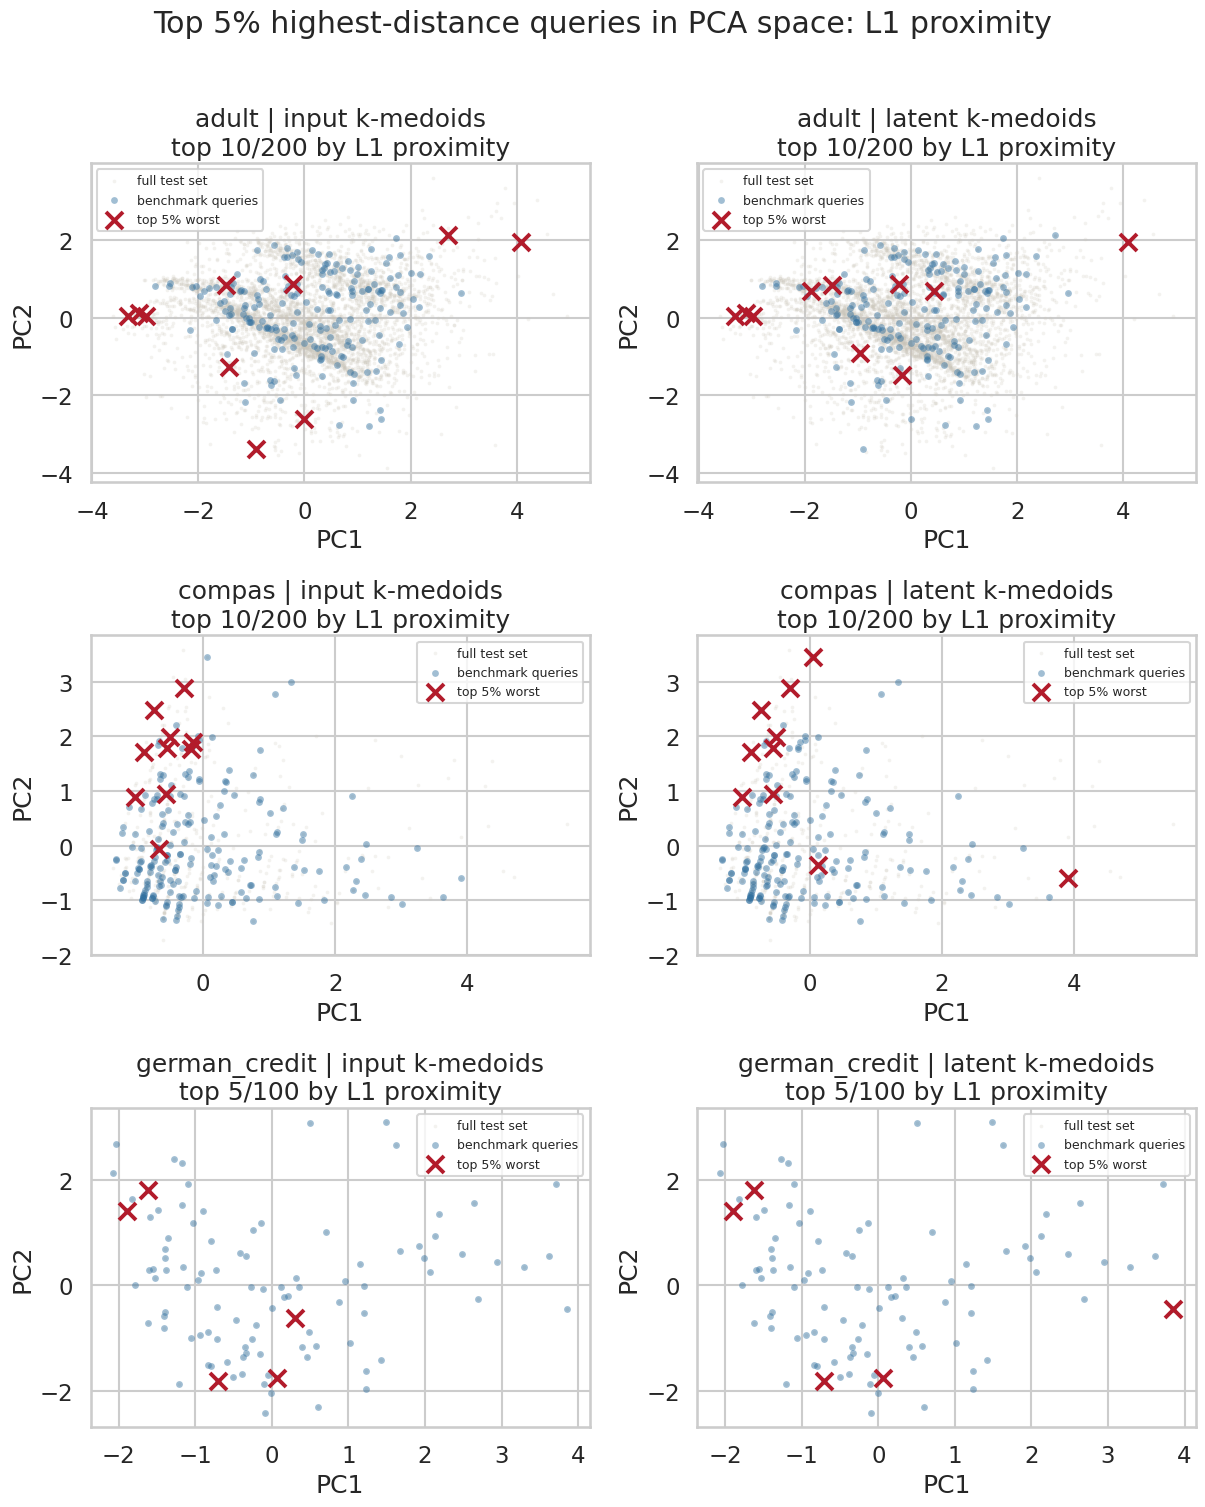

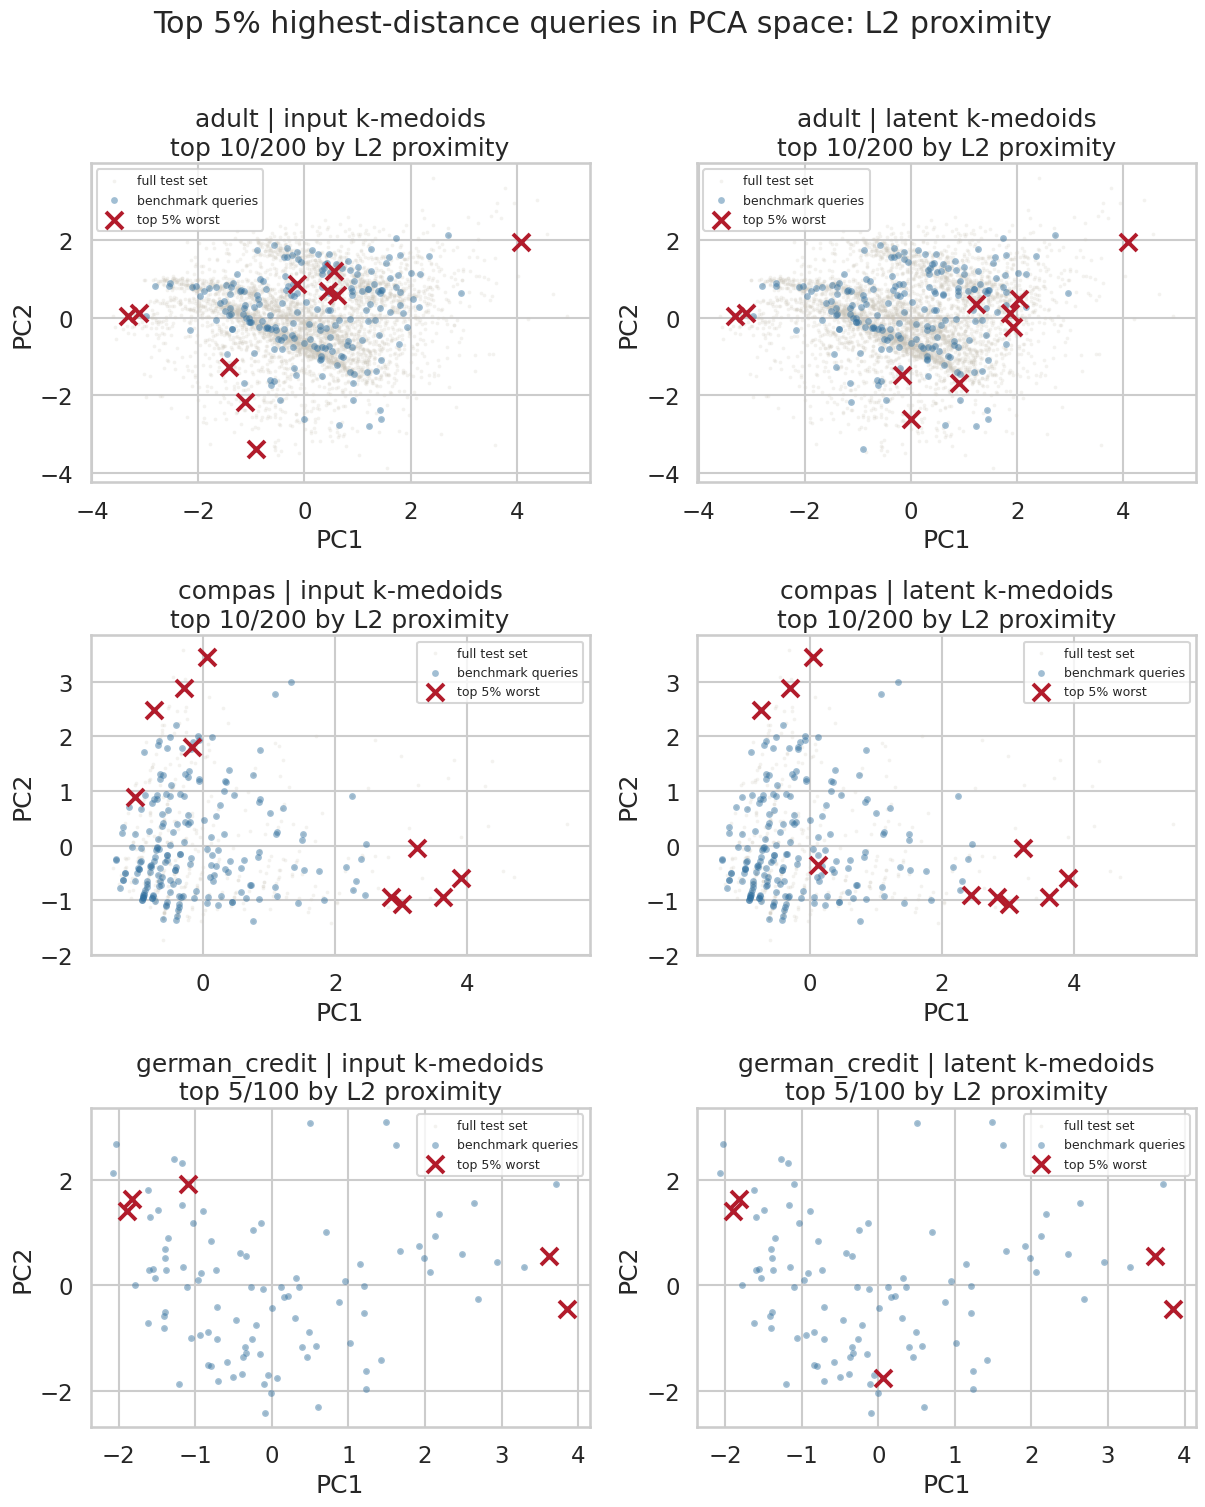

In [8]:
tail_summary_rows = []

for metric, metric_label in TAIL_METRICS:
    fig, axes = plt.subplots(
        nrows=len(datasets),
        ncols=len(method_order),
        figsize=(6.2 * len(method_order), 5.0 * len(datasets)),
        squeeze=False,
    )

    for r, dataset in enumerate(datasets):
        projection = projection_cache[dataset]
        coords = projection['coords']
        query_idx_to_row = projection['query_idx_to_row']

        for c, method in enumerate(method_order):
            ax = axes[r, c]
            method_df = success_df[
                (success_df['dataset'] == dataset)
                & (success_df['method'] == method)
                & success_df[metric].notna()
            ].copy()

            ax.scatter(coords[:, 0], coords[:, 1], s=7, c='#c9c4b8', alpha=0.22, linewidths=0, label=projection['source'])

            if method_df.empty:
                ax.set_title(f'{dataset} | {method_label_by_name.get(method, method)}\nno successful rows')
                ax.set_axis_off()
                continue

            query_rows = method_df['query_idx'].map(query_idx_to_row).dropna().astype(int).to_numpy()
            if len(query_rows):
                ax.scatter(coords[query_rows, 0], coords[query_rows, 1], s=24, c='#2f6f9f', alpha=0.45, linewidths=0, label='benchmark queries')

            n_top = max(1, int(np.ceil(TOP_FRACTION * len(method_df))))
            top_df = method_df.nlargest(n_top, metric)
            top_rows = top_df['query_idx'].map(query_idx_to_row).dropna().astype(int).to_numpy()
            if len(top_rows):
                ax.scatter(
                    coords[top_rows, 0],
                    coords[top_rows, 1],
                    marker='x',
                    s=150,
                    c='#b21b2b',
                    linewidths=2.8,
                    label=f'top {TOP_FRACTION:.0%} worst',
                )

            cutoff = float(top_df[metric].min())
            tail_summary_rows.append({
                'dataset': dataset,
                'method': method_label_by_name.get(method, method),
                'metric': metric_label,
                'n_success': int(len(method_df)),
                'n_top': int(len(top_df)),
                'tail_cutoff': cutoff,
                'tail_mean': float(top_df[metric].mean()),
                'overall_mean': float(method_df[metric].mean()),
            })

            ax.set_title(
                f'{dataset} | {method_label_by_name.get(method, method)}\n'
                f'top {len(top_df)}/{len(method_df)} by {metric_label}'
            )
            ax.set_xlabel('PC1')
            ax.set_ylabel('PC2')
            ax.legend(loc='best', fontsize=9, frameon=True)

    fig.suptitle(f'Top {TOP_FRACTION:.0%} highest-distance queries in PCA space: {metric_label}', y=1.01)
    fig.tight_layout()
    out_path = FIGURE_DIR / f'certcf_top5_worst_queries_2d_{metric}.png'
    fig.savefig(out_path, dpi=180, bbox_inches='tight')
    print(out_path)

tail_summary = pd.DataFrame(tail_summary_rows)
display(tail_summary.sort_values(['metric', 'dataset', 'method']))


## Notes

- This notebook reads saved parquet results only.
- It does not include notebook-only selectors such as `weighted_kmedoids_z` unless their per-query rows are saved to a parquet first.
- If we want the same distribution analysis for `weighted_kmedoids_z`, update `6.12` to persist its `pilot_df` before plotting.